In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image 
import cv2 
from scipy.signal import convolve2d

# 2.2.1 Rotation Property of the FT

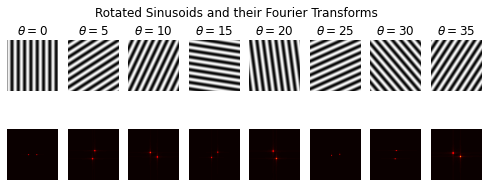

In [2]:
# First we create a 2D sinusoid

nx = 100 
ny = 100 
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y)

f = 4 # we can change this frequency later

Z = np.sin(2*np.pi*f*X)

# We take the FFT of the unrotated sinusoid
Z_fft = np.fft.fft2(Z)
Z_fft_shifted = np.fft.fftshift(Z_fft)
Z_fft_shifted_abs = np.abs(Z_fft_shifted)
# plt.imshow(Z_fft_shifted_abs)

# Now we rotate it and take its FFT

theta_array = [5, 10, 15, 20, 25, 30, 35, 1]  # LAST ELEMENT SHOULD BE A DUMMY and will not matter
                                               # you can maybe fix the indexing but that's your problem
                                               # future me! 
        
Z_rotated_array = np.empty(np.shape(Z))                  # array of rotated sinusoids
Z_rotated_fft_shifted_abs_array = np.empty(np.shape(Z))  # array of rotated sine FTs

for theta in theta_array:
    Z_rotated = np.sin(2*np.pi*f*(Y*np.sin(theta)+(X*np.cos(theta))))  # rotate the sinusoid
    Z_rotated_fft = np.fft.fft2(Z_rotated)
    Z_rotated_fft_shifted = np.fft.fftshift (Z_rotated_fft)
    Z_rotated_fft_shifted_abs = np.abs(Z_rotated_fft_shifted)          # here is the FT
    
    # Now we store with dstack
    Z_rotated_array = np.dstack((Z_rotated, Z_rotated_array))
    Z_rotated_fft_shifted_abs_array = np.dstack((Z_rotated_fft_shifted_abs_array, Z_rotated_fft_shifted_abs))

# Then we plot
fig, ax = plt.subplots(2, len(theta_array))
count = 0 
for i in range(len(theta_array)-1):
    ax[0,0].imshow(Z, cmap='gray')
    ax[0,i+1].imshow(Z_rotated_array[:,:,i], cmap='gray')
    ax[1,0].imshow(Z_fft_shifted_abs, cmap='hot')
    ax[1,i+1].imshow(Z_rotated_fft_shifted_abs_array[:,:,i+1], cmap='hot')
    
    ax[0,0].set_title('$\\theta = 0$')
    ax[0,i+1].set_title('$\\theta = $'+str(theta_array[i]))
    
    
for j in range(2):
    for k in range(len(theta_array)):
        ax[j, k].axis('off')
        
        
fig.suptitle('Rotated Sinusoids and their Fourier Transforms')        
fig.set_size_inches(8.5, 3.0, forward=False)
fig.savefig('Results/Rotating Sinusoid and their FTs',dpi=1000)

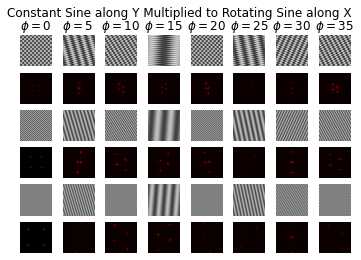

In [3]:
# Now we take the products of sinusoids and observe their FTs

Zprod1 = (np.sin(2*np.pi*f*X))*(np.sin(2*np.pi*f*Y))
Zprod1_fft = np.fft.fft2(Zprod1)
Zprod1_fft_shifted = np.fft.fftshift(Zprod1_fft)
Zprod1_fft_shifted_abs = np.abs(Zprod1_fft_shifted)    # no rotation yet

# Let's vary the frequency 
Zprod1_2f = (np.sin(2*np.pi*2*f*X))*(np.sin(2*np.pi*2*f*Y))  # double frequency
Zprod1_2f_fft = np.fft.fft2(Zprod1_2f)
Zprod1_2f_fft_shifted = np.fft.fftshift(Zprod1_2f_fft)
Zprod1_2f_fft_shifted_abs = np.abs(Zprod1_2f_fft_shifted)    # no rotation yet

Zprod1_3f = (np.sin(2*np.pi*3*f*X))*(np.sin(2*np.pi*3*f*Y))  # triple frequency
Zprod1_3f_fft = np.fft.fft2(Zprod1_3f)
Zprod1_3f_fft_shifted = np.fft.fftshift(Zprod1_3f_fft)
Zprod1_3f_fft_shifted_abs = np.abs(Zprod1_3f_fft_shifted)    # no rotation yet

# Now, we rotate the sinusoid along X 
phi_array = [5, 10, 15, 20, 25, 30, 35, 1]

Zprod_rotated_array = np.empty(np.shape(Zprod1))    
Zprod_rotated_fft_shifted_abs_array = np.empty(np.shape(Zprod1))  

Zprod_rotated_2f_array = np.empty(np.shape(Zprod1_2f))  
Zprod_rotated_3f_array = np.empty(np.shape(Zprod1_3f))  
Zprod_rotated_2f_fft_shifted_abs_array = np.empty(np.shape(Zprod1))  # frequency is doubled
Zprod_rotated_3f_fft_shifted_abs_array = np.empty(np.shape(Zprod1))  # frequency is tripled

for phi in phi_array:
    # We rotate the sinusoid that was oriented along X
    Zprod_rotated = (np.sin(2*np.pi*f*((X*np.cos(phi))+(Y*np.sin(phi)))))*(np.sin(2*np.pi*f*Y)) 
    Zprod_rotated_fft = np.fft.fft2(Zprod_rotated)
    Zprod_rotated_fft_shifted = np.fft.fftshift (Zprod_rotated_fft)
    Zprod_rotated_fft_shifted_abs = np.abs(Zprod_rotated_fft_shifted)          # here is the FT
    
    # Now we store with dstack
    Zprod_rotated_array = np.dstack((Zprod_rotated, Zprod_rotated_array))
    Zprod_rotated_fft_shifted_abs_array = np.dstack((Zprod_rotated_fft_shifted_abs_array, Zprod_rotated_fft_shifted_abs))

    # We rotate the sinusoid of double frequency 
    Zprod_rotated_2f = (np.sin(2*np.pi*2*f*((X*np.cos(phi))+(Y*np.sin(phi)))))*(np.sin(2*np.pi*2*f*Y))
    Zprod_rotated_2f_fft = np.fft.fft2(Zprod_rotated_2f)
    Zprod_rotated_2f_fft_shifted = np.fft.fftshift(Zprod_rotated_2f_fft)
    Zprod_rotated_2f_fft_shifted_abs = np.abs(Zprod_rotated_2f_fft_shifted)          # here is the FT
    
    Zprod_rotated_3f = (np.sin(2*np.pi*3*f*((X*np.cos(phi))+(Y*np.sin(phi)))))*(np.sin(2*np.pi*3*f*Y))
    Zprod_rotated_3f_fft = np.fft.fft2(Zprod_rotated_3f)
    Zprod_rotated_3f_fft_shifted = np.fft.fftshift(Zprod_rotated_3f_fft)
    Zprod_rotated_3f_fft_shifted_abs = np.abs(Zprod_rotated_3f_fft_shifted)          # here is the FT
    
    # Now we store with dstack
    Zprod_rotated_2f_array = np.dstack((Zprod_rotated_2f, Zprod_rotated_2f_array))
    Zprod_rotated_2f_fft_shifted_abs_array = np.dstack((Zprod_rotated_2f_fft_shifted_abs_array, Zprod_rotated_2f_fft_shifted_abs))
    
    Zprod_rotated_3f_array = np.dstack((Zprod_rotated_3f, Zprod_rotated_3f_array))
    Zprod_rotated_3f_fft_shifted_abs_array = np.dstack((Zprod_rotated_3f_fft_shifted_abs_array, Zprod_rotated_3f_fft_shifted_abs))

# Then we plot
fig, ax = plt.subplots(6, len(phi_array))
count = 0 
for i in range(len(phi_array)-1):
    ax[0,0].imshow(Zprod1, cmap='gray')
    ax[0,i+1].imshow(Zprod_rotated_array[:,:,i], cmap='gray')  # first row
    ax[1,0].imshow(Zprod1_fft_shifted_abs, cmap='hot')
    ax[1,i+1].imshow(Zprod_rotated_fft_shifted_abs_array[:,:,i+1], cmap='hot')  # second row
    
    ax[2,0].imshow(Zprod1_2f, cmap='gray')
    ax[2,i+1].imshow(Zprod_rotated_2f_array[:,:,i], cmap='gray')  # third row
    ax[3,0].imshow(Zprod1_2f_fft_shifted_abs,cmap='gray')
    ax[3,i+1].imshow(Zprod_rotated_2f_fft_shifted_abs_array[:,:,i+1], cmap='hot')  # fourth row
    
    ax[4,0].imshow(Zprod1_3f, cmap='gray')
    ax[4,i+1].imshow(Zprod_rotated_3f_array[:,:,i], cmap='gray')  # fifth row
    ax[5,0].imshow(Zprod1_3f_fft_shifted_abs,cmap='gray')
    ax[5,i+1].imshow(Zprod_rotated_3f_fft_shifted_abs_array[:,:,i+1], cmap='hot')  # sixth row
    
    ax[0,0].set_title('$\phi = 0$')
    ax[0,i+1].set_title('$\phi = $'+str(phi_array[i]))
    
    
for j in range(6):
    for k in range(len(phi_array)):
        ax[j, k].axis('off')
        
        
fig.suptitle('Constant Sine along Y Multiplied to Rotating Sine along X')        
fig.savefig('Results/Rotating Sinusoid Products and their FTs',dpi=2000)

# 2.2.2 Canvas Weave Modeling and Removal

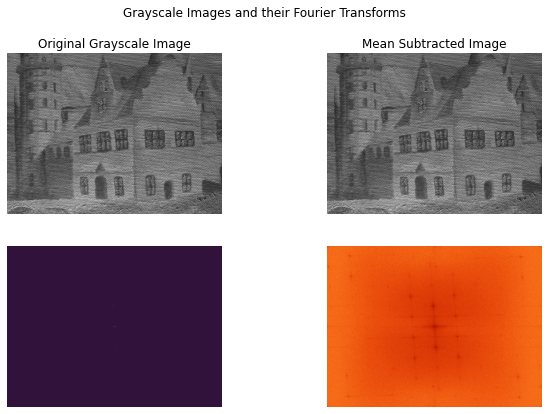

In [4]:
img = Image.open('Inputs/185-8526_IMG.png')
painting_GS = np.array(img.convert('L')) 

# Now we remove the DC bias to make the repeating patterns more evident so that we can see the FT clearly
mean_subtracted_painting_GS = painting_GS - painting_GS.mean() 
mean_subtracted_painting_GS_fft_shifted_abs = np.log(np.abs(np.fft.fftshift(np.fft.fft2(mean_subtracted_painting_GS))))
# plt.axis('off')
# plt.imshow(mean_subtracted_painting_GS_fft_shifted_abs, cmap='turbo')
# plt.imsave('Results/Mean Subtracted GS Painting FT.png', mean_subtracted_painting_GS_fft_shifted_abs, cmap='turbo')

fig, ax = plt.subplots(2,2)
ax[0,0].imshow(painting_GS, cmap='gray')
ax[0,1].imshow(mean_subtracted_painting_GS,cmap='gray')

ax[1,0].imshow(np.abs(np.fft.fftshift(np.fft.fft2(painting_GS))),cmap='turbo')
ax[1,1].imshow(np.log((np.abs(np.fft.fftshift(np.fft.fft2(mean_subtracted_painting_GS))))),cmap='turbo')

ax[0,0].set_title('Original Grayscale Image')
ax[0,1].set_title('Mean Subtracted Image')

for i in range(2):
    for j in range(2):
        ax[i,j].axis('off')

fig.suptitle('Grayscale Images and their Fourier Transforms')
fig.set_size_inches(10.5, 6.5, forward=False)

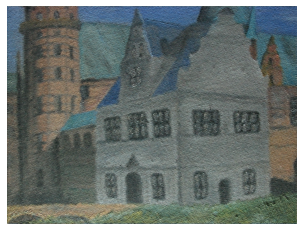

In [5]:
# We manually make a filter mask using canva.com - now we import it
# NOTE DO NOT MASK THE SPIKE AT THE CENTER SINCE THIS IS WHERE IMAGE INFO IS STORED
# WE ONLY WANT TO REMOVE THE SINUSOIDS (THE PEAKS AT THE SIDES)

img_filter = Image.open('Inputs/Painting Filter Mask Best.png')
# img_filter = Image.open('Inputs/Painting Filter Enhancer.png')
painting_filter_mask = np.array(img_filter.convert('L')) 

# plt.title('Filter Mask')
# plt.axis('off')
# plt.imshow(painting_filter_mask, cmap='gray')

# Since this is in the Fourier domain, we shift it 
painting_filter_mask_shifted = np.fft.fftshift(painting_filter_mask)



# We will now multiply this to the RGB channel of the painting's Fourier Ts (not mean corrected)
 
painting = np.array(img)/255   # 3 matrices with vals from 0-255 converted to 0-1
painting_red_fft = np.fft.fft2(painting[:,:,0])
painting_grn_fft = np.fft.fft2(painting[:,:,1])
painting_blu_fft = np.fft.fft2(painting[:,:,2])

painting_red_filtered_FT = painting_red_fft*painting_filter_mask_shifted
painting_grn_filtered_FT = painting_grn_fft*painting_filter_mask_shifted
painting_blu_filtered_FT = painting_blu_fft*painting_filter_mask_shifted

# Note that this is basically a convolution since we are multiplying in the Fourier space. 
# Since the filters zeroed the peaks of the painting's FT (cuz we multiplied) - the patterns
# should be gone now...

painting_red_filtered = (np.round(np.abs(np.fft.ifft2(painting_red_filtered_FT)))).astype(np.uint8)
painting_grn_filtered = (np.round(np.abs(np.fft.ifft2(painting_grn_filtered_FT)))).astype(np.uint8)
painting_blu_filtered = (np.round(np.abs(np.fft.ifft2(painting_blu_filtered_FT)))).astype(np.uint8)


# we used inverse fourier transform, this introduced floats so we convert back to uint8 (0-255) 

painting_filtered = np.dstack((painting_red_filtered, painting_grn_filtered, painting_blu_filtered))
# np.shape(painting_filtered)
# painting_filtered.max()
# painting_filtered.min()
plt.axis('off')
plt.imshow(painting_filtered)

# plt.imsave('Results/Canvas Removed Painting.png', painting_filtered)
# plt.imsave('Results/Canvas Isolated from Painting.png', painting_filtered)

# To get the canvas weaves, invert the colors of the mask then run this cell

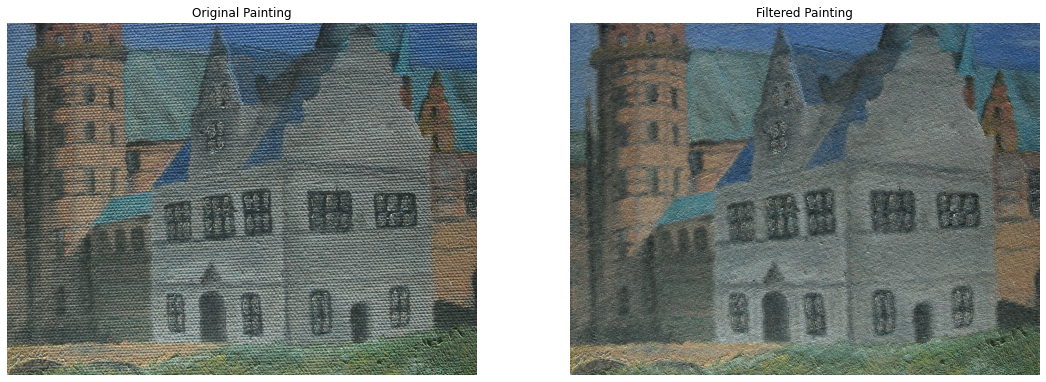

In [6]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(painting)
ax[1].imshow(painting_filtered)
ax[0].set_title('Original Painting')
ax[1].set_title('Filtered Painting')
for i in range(2):
    ax[i].axis('off')
fig.set_size_inches(18.5, 10.5, forward=True)
# fig.savefig('Results/Painting.png',dpi=500)

# 2.2.3 Convolution Theorem Redux

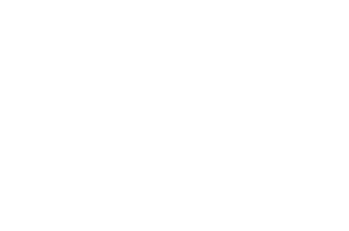

In [7]:
n = 64
two_dots = np.ones((n, n))
two_dots[np.rint(n/2).astype(np.uint8), np.rint(n/3).astype(np.uint8)]=0
two_dots[np.rint(n/2).astype(np.uint8), np.rint(n/1.5).astype(np.uint8)]=0
plt.axis('off')
# plt.imshow(two_dots, cmap='gray')

two_dots_fft = np.fft.fft2(two_dots)
two_dots_fft_shifted = np.fft.fftshift(two_dots_fft)
two_dots_fft_shifted_abs = np.abs(two_dots_fft_shifted)
# plt.imshow(np.log(two_dots_fft_shifted_abs), cmap='gray')

# fig, ax = plt.subplots(1,2)
# ax[0].imshow(two_dots, cmap='gray')
# ax[1].imshow(np.log(two_dots_fft_shifted_abs), cmap='hot')
# ax[0].set_title('Synthetic Image of Two Dots')
# ax[1].set_title('Fourier Transform in Log Scale')
# for i in range(2):
#     ax[i].axis('off')
# fig.set_size_inches(18.5, 10.5, forward=True)
# fig.savefig('Results/twodots_and_FT.png',dpi=500)


In [8]:
N = 512

x = np.linspace(-1, 1, num=N)
y = x
X, Y = np.meshgrid(x,y)


R1 = np.sqrt((X-0.3)**2 + Y**2)
R2 = np.sqrt((X+0.3)**2 + Y**2)
two_circles = (np.zeros(np.shape(R1))).astype(np.uint8)
two_circles[np.where(R1<0.02)] = 255
two_circles[np.where(R2<0.02)] = 255
# plt.axis('off')
# plt.imshow(two_circles, cmap = 'gray')

two_circles_fft = np.fft.fft2(two_circles)
two_circles_fft_shifted = np.fft.fftshift(two_circles_fft)
two_circles_fft_shifted_abs = np.abs(two_circles_fft_shifted)
# plt.imshow(two_circles_fft_shifted_abs, cmap='hot')

# fig, ax = plt.subplots(1,2)
# ax[0].imshow(two_circles, cmap='gray')
# ax[1].imshow(two_circles_fft_shifted_abs, cmap='hot')
# ax[0].set_title('Synthetic Image of Two Small Circles')
# ax[1].set_title('Fourier Transform in Linear Scale')
# for i in range(2):
#     ax[i].axis('off')
# fig.set_size_inches(18.5, 10.5, forward=True)
# fig.savefig('Results/twocircles_and_FT.png',dpi=500)


In [9]:
two_squares = (np.zeros(np.shape(R1))).astype(np.uint8)
cv2.rectangle(two_squares, pt1 = (186,246), pt2 = (206,266), color =(255,255,255), thickness=-1)
cv2.rectangle(two_squares, pt1 = (326,246), pt2 = (306,266), color =(255,255,255), thickness=-1)

# plt.axis('off')
# plt.imshow(two_squares,cmap='gray')

two_squares_fft = np.fft.fft2(two_squares)
two_squares_fft_shifted = np.fft.fftshift(two_squares_fft)
two_squares_fft_shifted_abs = np.abs(two_squares_fft_shifted)

# plt.imshow(two_squares_fft_shifted_abs, cmap='hot')


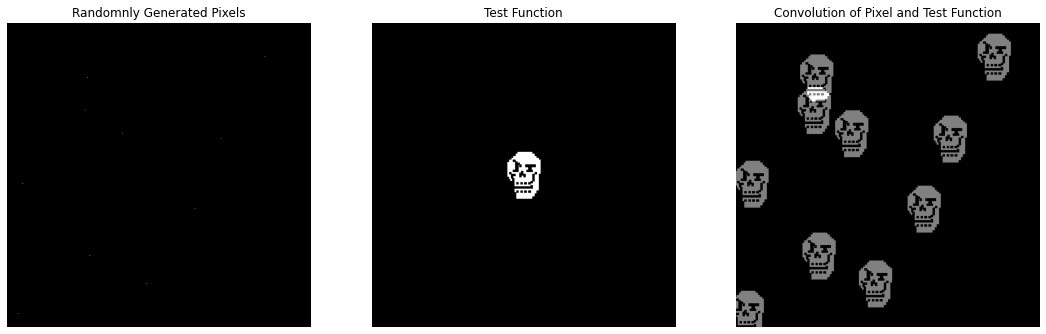

In [10]:
# I already defined a convolution function in the previous activities, here let's just use
# scipy instead since I want to know if it works fine. 
resolution = 512    
random_deltas = np.zeros((resolution,resolution))
num_deltas = 10
i = 0
while i < num_deltas:
    random_deltas[np.random.randint(0,resolution),np.random.randint(0,resolution)] = 1
    i+=1
# plt.imshow(random_deltas, cmap = 'gray')

img_pattern = Image.open('Inputs/Pattern 11.png')
pattern_GS = (np.array(img_pattern.convert('L'))/255).astype(int)
# plt.imshow(pattern_GS, cmap='gray')

convolve_random_deltas = convolve2d(pattern_GS, random_deltas, mode='same')
# plt.imshow(convolve_random_deltas, cmap='gray')

fig, ax = plt.subplots(1,3)
ax[0].imshow(random_deltas, cmap = 'gray')
ax[1].imshow(pattern_GS, cmap='gray')
ax[2].imshow(convolve_random_deltas, cmap='gray')
ax[0].set_title('Randomnly Generated Pixels')
ax[1].set_title('Test Function')
ax[2].set_title('Convolution of Pixel and Test Function')
for i in range(3):
    ax[i].axis('off')
fig.set_size_inches(18.5, 10.5, forward=True)
fig.savefig('Results/randomdirac_convolve.png',dpi=500)


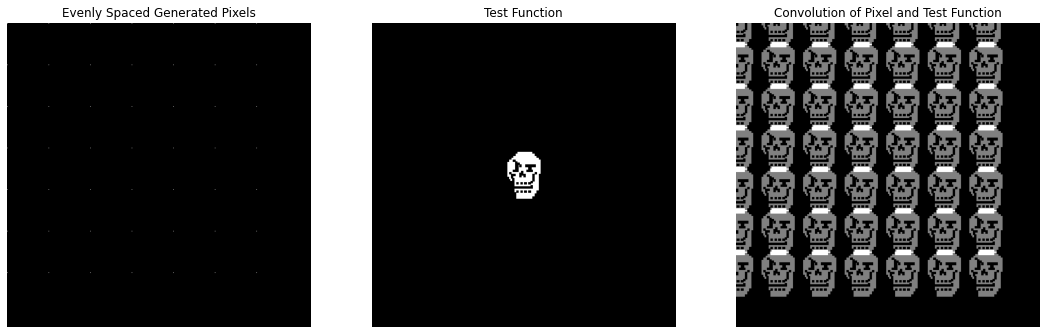

In [24]:
spaced_deltas = np.zeros((resolution,resolution))
step = 70
for i in range(0, resolution-step, step):
    for j in range(0, resolution-step, step):
        spaced_deltas[i,j] = 1
# plt.imshow(spaced_deltas, cmap='gray')

convolve_spaced_deltas = convolve2d(pattern_GS, spaced_deltas, mode='same')
# plt.imshow(convolve_spaced_deltas, cmap='gray')

# fig, ax = plt.subplots(1,3)
# ax[0].imshow(spaced_deltas, cmap = 'gray')
# ax[1].imshow(pattern_GS, cmap='gray')
# ax[2].imshow(convolve_spaced_deltas, cmap='gray')
# ax[0].set_title('Evenly Spaced Generated Pixels')
# ax[1].set_title('Test Function')
# ax[2].set_title('Convolution of Pixel and Test Function')
# for i in range(3):
#     ax[i].axis('off')
# fig.set_size_inches(18.5, 10.5, forward=True)
# fig.savefig('Results/evenspaceddirac_convolve.png',dpi=500)

# 2.2.4 Fingerprints: Ridge Enhancement

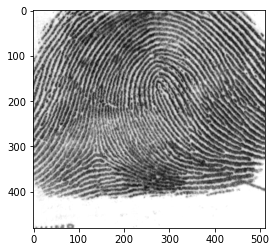

In [12]:
fingerprint_GS = np.array(Image.open('Inputs/Fingerprint 1.png'))
plt.imshow(fingerprint_GS, cmap='gray')
fingerprint_GS_mean_centered = fingerprint_GS - fingerprint_GS.mean()
# plt.imshow(fingerprint_GS_mean_centered, cmap='gray')
fingerprint_GS_mean_centered_fft_shifted_abs = np.abs(np.fft.fftshift(np.fft.fft2(fingerprint_GS_mean_centered)))
# plt.imshow(np.log(fingerprint_GS_mean_centered_fft_shifted_abs),cmap='turbo')
# plt.imsave('Results/Fingerprint FFT.png', np.log(fingerprint_GS_mean_centered_fft_shifted_abs), cmap='turbo')

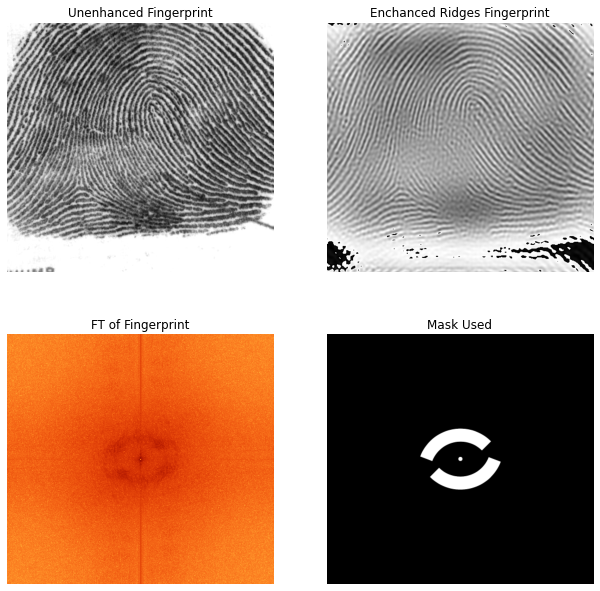

In [25]:
img_fingerprint_filter = Image.open('Inputs/Fingerprint Mask 16.png')
fingerprint_filter_mask = np.array(img_fingerprint_filter.convert('L'))           # import mask as array
fingerprint_filter_mask_shifted = np.fft.fftshift(fingerprint_filter_mask) # we shift since it's in the FT space
fingerprint = fingerprint_GS/255                                           # from 0-255 to 0-1
fingerprint_fft = np.fft.fft2(fingerprint)                                 # transition to FT space
fingerprint_filtered_FT = fingerprint_fft*fingerprint_filter_mask_shifted       # multiply in FT space
fingerprint_filtered = (np.round(np.abs(np.fft.ifft2(fingerprint_filtered_FT)))).astype(np.uint8)  # amogus
# plt.imshow(fingerprint_filtered, cmap='gray')
# plt.imsave('Results/Fingerprint Image Filtered.png', fingerprint_filtered, cmap='gray')

# fig, ax = plt.subplots(2,2)
# ax[0,0].imshow(fingerprint_GS, cmap = 'gray')
# ax[0,1].imshow(fingerprint_filtered, cmap='gray')
# ax[1,0].imshow(np.log(fingerprint_GS_mean_centered_fft_shifted_abs),cmap='turbo')
# ax[1,1].imshow(fingerprint_filter_mask, cmap='gray')
# ax[0,0].set_title('Unenhanced Fingerprint')
# ax[0,1].set_title('Enchanced Ridges Fingerprint')
# ax[1,0].set_title('FT of Fingerprint')
# ax[1,1].set_title('Mask Used')
# for i in range(2):
#     for j in range(2):
#         ax[i,j].axis('off')
# fig.set_size_inches(10.5, 10.5, forward=True)
# fig.savefig('Results/fingerprint_ridges.png',dpi=500)

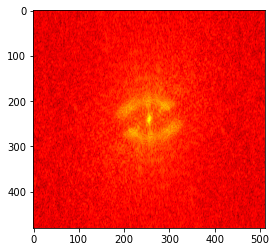

In [44]:
'''
We can use the same mask and apply the same procedure to the enhanced images. 
This will binarize the fingerprint and will very clearly expose the ridges. 
However, this is trivial already so I'm just gonna leave this draft here
and then maybe future me will revisit and add the necessary code. 
'''

binarized_FT = np.abs(np.fft.fftshift(np.fft.fft2(fingerprint_filtered)))
# plt.imshow(np.log(binarized_FT), cmap='hot')

The image is of a fingerprint, which exhibits unsymmetric sinusoids wrapped aroung the center. The circular pattern near the center of the Fourier space is due to the swirl of the fingerprint - sinusoids of the same frequency but of different angles combine to produce a ring in the Fourier space (see the activity where I rotated sinusoids then provided FT space). On the other hand, the apparent horizontal and vertical lines in the FT space is due to the small ridges in the image that really don't connect to a defined fingerprint line. These lone ridges essentially act as paired dots since they are obviously not alone in the image, and together they produce the lines in the FT space. Lastly, the mass at the center of the FT space is due to the image qualities itself - this is not noise and so we would not filter this out if ever. 

# 2.2.5 Lunar Landing Scanned Pictures : Line Removal

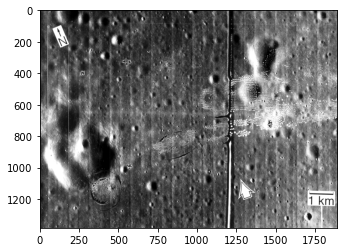

In [14]:
img_apollo = Image.open('Inputs/ApolloLand05.tif')
apollo_GS = np.array(img_apollo.convert('L')) 
plt.imshow(apollo_GS, cmap='gray')

apollo_GS_mean_centered = apollo_GS - apollo_GS.mean()
apollo_GS_mean_centered_fft_shifted_abs = np.abs(np.fft.fftshift(np.fft.fft2(apollo_GS_mean_centered)))

# plt.imshow(np.log(apollo_GS_mean_centered_fft_shifted_abs), cmap='turbo')   # don't forget log scale
# plt.imsave('Results/Apollo FFT.png', np.log(apollo_GS_mean_centered_fft_shifted_abs), cmap='turbo')


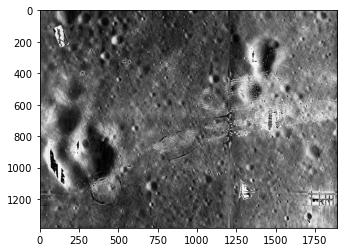

In [15]:
img_apollo_filter = Image.open('Inputs/Apollo Mask 4.png')
apollo_filter_mask = np.array(img_apollo_filter.convert('L'))           # import mask as array
apollo_filter_mask_shifted = np.fft.fftshift(apollo_filter_mask) # we shift since it's in the FT space
apollo = apollo_GS/255                                           # from 0-255 to 0-1
apollo_fft = np.fft.fft2(apollo)                                 # transition to FT space
apollo_filtered_FT = apollo_fft*apollo_filter_mask_shifted       # multiply in FT space
apollo_filtered = (np.round(np.abs(np.fft.ifft2(apollo_filtered_FT)))).astype(np.uint8)  # amogus

plt.imshow(apollo_filtered, cmap='gray')
# plt.imsave('Results/Apollo Image Filtered.png', apollo_filtered, cmap='gray')

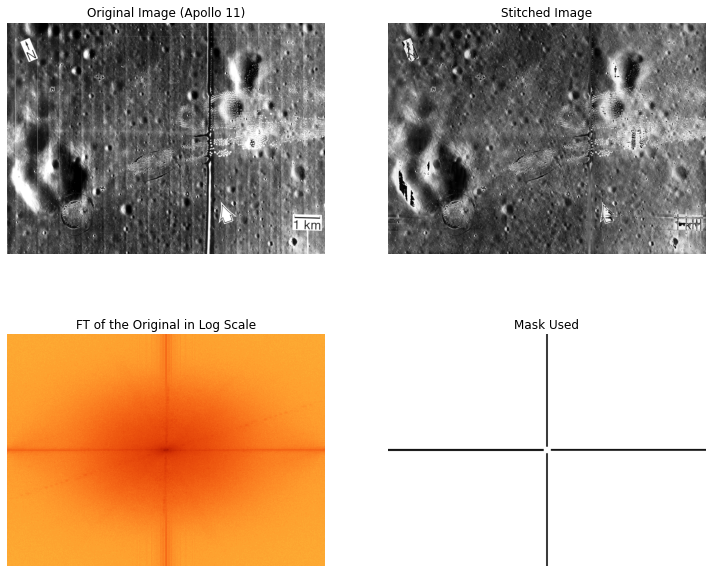

In [47]:
fig, ax = plt.subplots(2,2)
ax[0,0].imshow(apollo, cmap='gray')
ax[0,1].imshow(apollo_filtered, cmap='gray')
ax[1,0].imshow(np.log(apollo_GS_mean_centered_fft_shifted_abs),cmap='turbo')
ax[1,1].imshow(apollo_filter_mask, cmap='gray')

ax[0,0].set_title('Original Image (Apollo 11)')
ax[0,1].set_title('Stitched Image')
ax[1,0].set_title('FT of the Original in Log Scale')
ax[1,1].set_title('Mask Used')
for i in range(2):
    for j in range(2):
        ax[i,j].axis('off')
fig.set_size_inches(12.5, 10.5, forward=True)
fig.savefig('Results/Apollo.png',dpi=500)

In [17]:
# yey now i can play ultrakill and do the killing when it is ultra ;000000